[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanglab-broad/FuseMap/blob/main/docs/notebooks/10_gene_panel_selection.ipynb)

In [ ]:
# Requires a Python 3.9-3.11 runtime. For local setup, see docs/install.rst.
import sys
if not (3, 9) <= sys.version_info[:2] < (3, 12):
    raise RuntimeError("FuseMap requires Python 3.9-3.11. Select a compatible runtime or use the local setup.")
if "google.colab" in sys.modules:
    %pip install -q "fusemap[tutorials]"


# Design a targeted gene panel with the universal gene embedding

Targeted spatial platforms (MERFISH, Xenium, CosMx) measure only a few hundred
genes, so **which** genes you put on the panel decides what biology you can see.
FuseMap's **universal gene embedding** places every gene in a 64-dimensional space
where proximity reflects shared function — genes in the same pathway or protein
family sit close together. We can exploit this structure to build a **compact,
module-balanced panel** that covers many functional programs instead of piling up
redundant high-expression genes.

This tutorial:
1. clusters the gene embedding into functional **modules**,
2. checks whether selected known gene families concentrate within modules,
3. selects **module-balanced panels** of 30 and 100 genes, and
4. benchmarks a balanced 100-gene panel against a plain top-100 highly-variable
   panel for module coverage and within-section cell-type classification.

> **Prerequisite:** run **Tutorial 2 (spatial integration, sequencing-based)**
> first — it produces `output_tutorial2/ad_gene_embedding.h5ad`, the gene
> embedding used here.

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
GENE_EMB = "output_tutorial2/ad_gene_embedding.h5ad"
STEREO   = "tutorial2_data/stereoseq_mousebrain.h5ad"

if not os.path.exists(GENE_EMB):
    raise FileNotFoundError(
        f"{GENE_EMB} not found. Run Tutorial 2 (spatial integration, "
        "sequencing-based) first to produce the universal gene embedding."
    )

adg = sc.read_h5ad(GENE_EMB)
adg.obs_names = adg.obs_names.str.upper()          # gene symbols, uppercase
print(f"gene embedding: {adg.shape[0]} genes x {adg.shape[1]} dims")

gene embedding: 25781 genes x 64 dims


/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-p

## 1. Cluster the gene embedding into functional modules

We build a neighbor graph directly on the 64-d embedding and run Leiden,
choosing a resolution that gives roughly 13 modules. **This is a teaching
adaptation:** the manuscript uses WGCNA to define 13 gene modules. Leiden modules
from this small integration are not the manuscript modules and need not have
the same biological interpretation.

In [3]:
sc.pp.neighbors(adg, use_rep="X", n_neighbors=15)

# auto-tune resolution to ~13 modules
target = 13
best = None
for res in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.6, 2.0]:
    sc.tl.leiden(adg, resolution=res, key_added="module",
                 n_iterations=2, directed=False)
    k = adg.obs["module"].nunique()
    if best is None or abs(k - target) < abs(best[1] - target):
        best = (res, k)
    if 10 <= k <= 16:
        break
sc.tl.leiden(adg, resolution=best[0], key_added="module",
             n_iterations=2, directed=False)
n_mod = adg.obs["module"].nunique()
print(f"resolution {best[0]} -> {n_mod} gene modules")
print(adg.obs["module"].value_counts().sort_index())

/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


resolution 0.7 -> 13 gene modules
module
0     7383
1     4905
2     4663
3     4619
4     1069
5      864
6      858
7      850
8      192
9      149
10     112
11      97
12      20
Name: count, dtype: int64


## 2. Visualize the module structure

/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ewsc/yhe/miniconda3/envs/FuseMap_952261_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


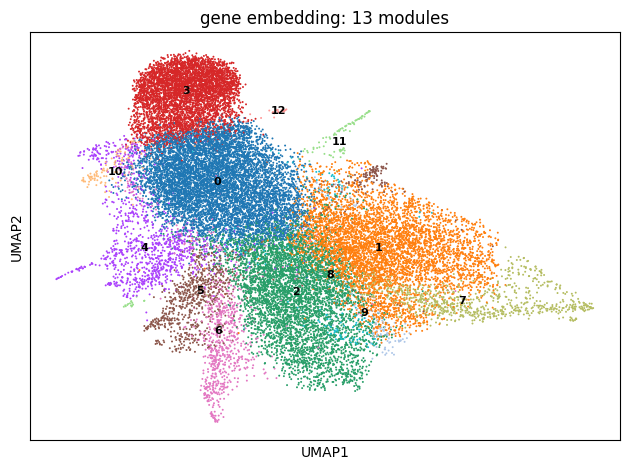

In [4]:
sc.tl.umap(adg)
sc.pl.umap(adg, color="module", size=8, title=f"gene embedding: {n_mod} modules",
           legend_loc="on data", legend_fontsize=8, show=False)
plt.tight_layout(); plt.show()

## 3. Sanity check: known gene families concentrate in a few modules

If the modules are functional, members of a curated gene family should not be
scattered uniformly — they should pile into one or two modules.

In [5]:
def family_members(prefixes):
    names = adg.obs_names
    return [g for g in names if any(g.startswith(p) for p in prefixes)]

families = {
    "Ribosomal (Rpl*/Rps*)": ["RPL", "RPS"],
    "Myelin/oligo (Mbp,Plp1,Mobp,Mog,Mag)": None,   # explicit list below
    "GABA-A receptor (Gabr*)": ["GABR"],
}
explicit = {"Myelin/oligo (Mbp,Plp1,Mobp,Mog,Mag)": ["MBP","PLP1","MOBP","MOG","MAG","CLDN11"]}

for fam, pref in families.items():
    genes = explicit[fam] if pref is None else family_members(pref)
    genes = [g for g in genes if g in adg.obs_names]
    if len(genes) < 3:
        print(f"{fam}: <3 members in vocabulary, skipping"); continue
    dist = adg.obs.loc[genes, "module"].value_counts()
    top = dist.index[0]
    frac = dist.iloc[0] / dist.sum()
    print(f"{fam}: {len(genes)} genes | top module {top} holds "
          f"{dist.iloc[0]}/{dist.sum()} ({frac:.0%}) | spread over "
          f"{dist[dist>0].shape[0]} of {n_mod} modules")

Ribosomal (Rpl*/Rps*): 104 genes | top module 7 holds 81/104 (78%) | spread over 7 of 13 modules
Myelin/oligo (Mbp,Plp1,Mobp,Mog,Mag): 6 genes | top module 6 holds 6/6 (100%) | spread over 1 of 13 modules
GABA-A receptor (Gabr*): 19 genes | top module 1 holds 6/19 (32%) | spread over 7 of 13 modules


## 4. Score gene variability from the spatial data

We rank genes by biological variability using Stereo-seq counts
(Seurat v3 HVG), restricted to genes present in the embedding. This score drives
the *within-module* selection.

In [6]:
ads = sc.read_h5ad(STEREO)
ads.var_names = ads.var_names.str.upper()
shared = [g for g in ads.var_names if g in set(adg.obs_names)]
ads = ads[:, shared].copy()
print(f"shared genes (stereo ∩ embedding): {len(shared)}")

sc.pp.highly_variable_genes(ads, n_top_genes=len(shared), flavor="seurat_v3")
hvg_score = ads.var["variances_norm"].reindex(shared)
adg_shared = adg[[g for g in adg.obs_names if g in set(shared)]].copy()
score = hvg_score.reindex(adg_shared.obs_names)
adg_shared.obs["hvg_score"] = score.values
adg_shared.obs["module"] = adg.obs.loc[adg_shared.obs_names, "module"].values
print(f"scored {adg_shared.n_obs} genes across {adg_shared.obs['module'].nunique()} modules")

shared genes (stereo ∩ embedding): 23483


scored 23483 genes across 13 modules


## 5. Select module-balanced panels (round-robin)

Within each module we sort genes by variability, then pick round-robin — the top
gene from every module, then the second from every module, and so on — until the
target panel size is reached. This guarantees even functional coverage.

In [7]:
def balanced_panel(df, size):
    # df: index=gene, cols=[module, hvg_score]
    ranked = (df.sort_values("hvg_score", ascending=False)
                .groupby("module", sort=True)
                .cumcount())                      # 0 = top gene in its module
    order = df.assign(rank=ranked).sort_values(["rank", "hvg_score"],
                                               ascending=[True, False])
    return order.index[:size].tolist()

sel_df = adg_shared.obs[["module", "hvg_score"]].dropna()
panel30  = balanced_panel(sel_df, 30)
panel100 = balanced_panel(sel_df, 100)

p30 = sel_df.loc[panel30, ["module"]].copy()
p30["hvg_score"] = sel_df.loc[panel30, "hvg_score"].round(2).values
print("30-gene module-balanced panel:")
print(p30.reset_index().rename(columns={"index": "gene"}).to_string(index=False))

30-gene module-balanced panel:
         gene module  hvg_score
       HBB-BS      4      16.38
          SST      1       5.91
       ADARB2      8       5.89
      GM28928      2       5.78
        TRPM3      5       5.75
         PLP1      6       4.25
      GM32647      9       3.30
4933405L10RIK      0       2.17
       GM9530      3       2.14
          TTR     11       1.73
       CLDN16     10       1.65
       CAMK1D      7       1.31
      GM35041     12       1.14
        PTGDS      4      15.22
       KCNIP4      2       5.62
        ERBB4      1       5.21
         GPC5      5       4.67
       NKAIN2      6       2.40
         RORA      8       2.23
         CHP2      0       2.07
      GM31898      3       2.00
        TRPS1      9       2.00
      GM19585     10       1.55
        TRP73     11       1.35
        TCTE2      7       1.20
      ADAMTS7     12       1.06
       HBA-A1      4      12.50
        PTPRD      2       5.54
          NPY      1       5.04
      GAL

/tmp/ipykernel_4141408/3319527036.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranked = (df.sort_values("hvg_score", ascending=False)
/tmp/ipykernel_4141408/3319527036.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranked = (df.sort_values("hvg_score", ascending=False)


## 6. Benchmark: module-balanced vs top-HVG vs random

Following the paper's panel task, we score each panel by **how well it classifies
cell types**: train an MLP on the panel's genes and measure held-out accuracy
(`sklearn` MLPClassifier, `alpha=1`, 3 seeds), against a top-HVG panel and a random
panel of the same size. We also report each panel's **module coverage**.

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def hvg_panel(size):
    return sel_df.sort_values("hvg_score", ascending=False).index[:size].tolist()
def random_panel(size, seed):
    return list(np.random.RandomState(seed).choice(sel_df.index, size, replace=False))

rng = np.random.RandomState(0)
n_sub = min(20000, ads.n_obs)
idx = rng.choice(ads.n_obs, n_sub, replace=False)
base = ads[idx].copy()
sc.pp.normalize_total(base, target_sum=1e4); sc.pp.log1p(base)
gt = base.obs["gt_cell_type_main"].astype(str).values
keep = gt != "nan"
X_all = base.X.toarray() if hasattr(base.X, "toarray") else np.asarray(base.X)
X_all, y = X_all[keep], gt[keep]
col = {g: i for i, g in enumerate(base.var_names)}
print(f"cell-type classification on {int(keep.sum())} cells, {len(set(y))} types\n")

def panel_accuracy(genes, seeds=(0, 1, 2)):
    cols = [col[g] for g in genes if g in col]
    accs = []
    for s in seeds:
        Xtr, Xte, ytr, yte = train_test_split(X_all[:, cols], y, test_size=0.3,
                                              random_state=s, stratify=y)
        clf = MLPClassifier(alpha=1, max_iter=1000, random_state=s).fit(Xtr, ytr)
        accs.append(accuracy_score(yte, clf.predict(Xte)))
    return np.mean(accs), np.std(accs)

for size, panel in [(30, panel30), (100, panel100)]:
    a_bal = panel_accuracy(panel)
    a_hvg = panel_accuracy(hvg_panel(size))
    a_rnd = panel_accuracy(random_panel(size, 7))
    cb = sel_df.loc[panel, "module"].nunique()
    ch = sel_df.loc[hvg_panel(size), "module"].nunique()
    print(f"panel size {size}:")
    print(f"  module-balanced : acc {a_bal[0]:.3f} ± {a_bal[1]:.3f}   coverage {cb}/{n_mod} modules")
    print(f"  top-HVG         : acc {a_hvg[0]:.3f} ± {a_hvg[1]:.3f}   coverage {ch}/{n_mod} modules")
    print(f"  random          : acc {a_rnd[0]:.3f} ± {a_rnd[1]:.3f}")

missed = sorted(set(sel_df["module"]) - set(sel_df.loc[hvg_panel(100), "module"]), key=int)
print(f"\nmodules the top-HVG-100 panel misses entirely: {missed}")

cell-type classification on 20000 cells, 29 types



panel size 30:
  module-balanced : acc 0.465 ± 0.003   coverage 13/13 modules
  top-HVG         : acc 0.493 ± 0.001   coverage 6/13 modules
  random          : acc 0.186 ± 0.000


panel size 100:
  module-balanced : acc 0.532 ± 0.002   coverage 13/13 modules
  top-HVG         : acc 0.537 ± 0.003   coverage 8/13 modules
  random          : acc 0.204 ± 0.001

modules the top-HVG-100 panel misses entirely: ['3', '7', '10', '11', '12']


## 6. Benchmark: module-balanced vs top-HVG vs random

We compare cell-type classification from the selected panels using an MLP
(`alpha=1`, three train/test split seeds), and report coverage of the Leiden
modules. In the saved example, the balanced and top-HVG 100-gene panels have
similar classification accuracy, while the balanced panel covers more modules.
Coverage here is defined by the tutorial's clustering; it is not independent
validation of functional coverage or an advantage on every downstream task.

This is an exploratory **within-section** comparison: the embedding and gene
variability scores use the full section before classifier splitting, and one
random panel is tested across three splits. It is not an independent held-out
panel-design benchmark or a reproduction of the paper's benchmark scores.


## 7. Spatial check: panel genes from different modules

Pick one gene from each of four different modules in the balanced panel and plot
its spatial expression on the Stereo-seq section.

plotting: [('HBB-BS', '4'), ('SST', '1'), ('ADARB2', '8'), ('GM28928', '2')]


/tmp/ipykernel_4141408/2750025147.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("module").head(1))


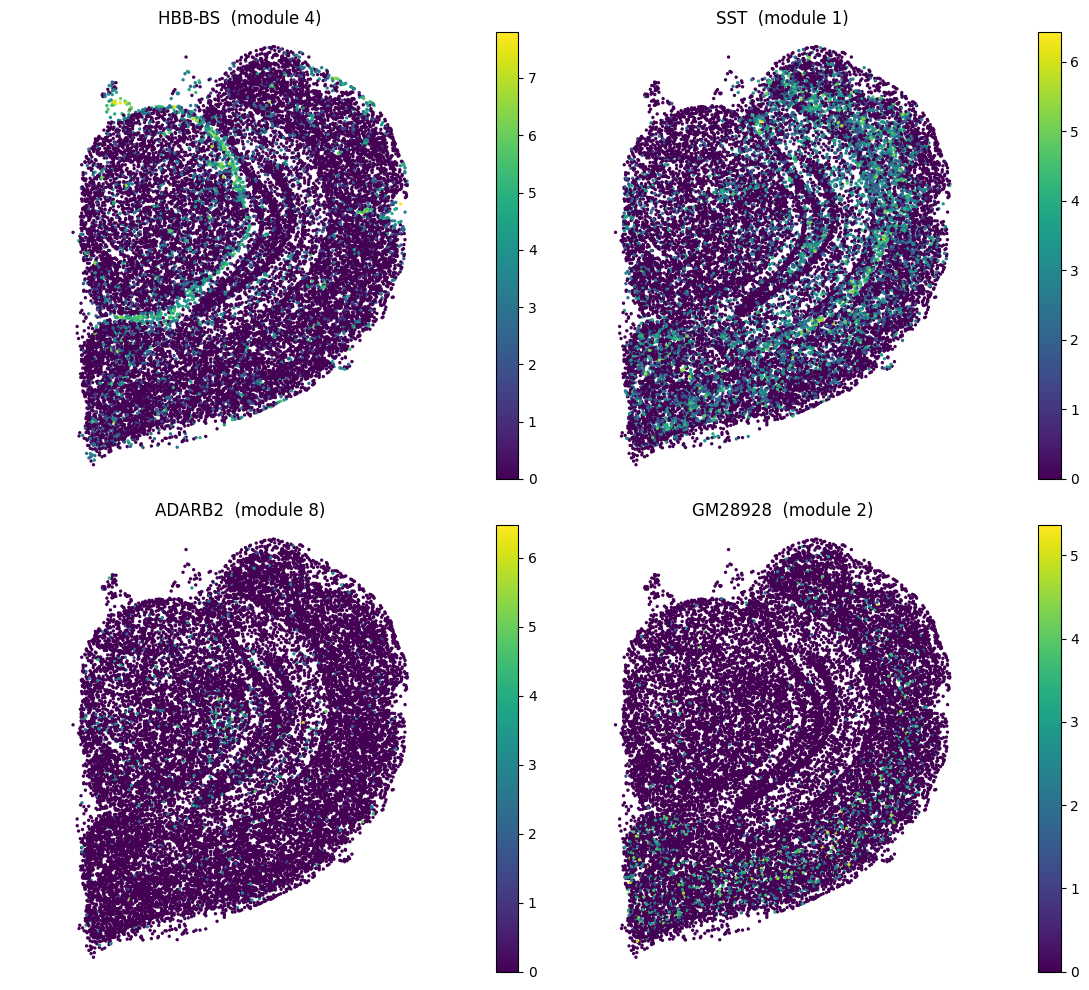

In [9]:
# one representative gene per module (highest score), take 4 distinct modules
reps = (sel_df.loc[panel100].sort_values("hvg_score", ascending=False)
        .groupby("module").head(1))
pick = reps.index[:4].tolist()
pick_mod = sel_df.loc[pick, "module"].tolist()
print("plotting:", list(zip(pick, pick_mod)))

viz = ads[idx].copy()
sc.pp.normalize_total(viz, target_sum=1e4); sc.pp.log1p(viz)
xy = viz.obs[["x", "y"]].values
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, g, m in zip(axes.ravel(), pick, pick_mod):
    expr = np.asarray(viz[:, g].X.todense()).ravel() if hasattr(viz[:, g].X, "todense") \
           else np.asarray(viz[:, g].X).ravel()
    sctp = ax.scatter(xy[:, 0], xy[:, 1], c=expr, s=2, cmap="viridis")
    ax.set_title(f"{g}  (module {m})"); ax.axis("equal"); ax.axis("off")
    plt.colorbar(sctp, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Adapt this to your own experiment

- **Any embedding works.** Run `fusemap` integration on your own atlas and feed the
  resulting `ad_gene_embedding.h5ad` here to design a panel tailored to your tissue.
- **Brain panels at scale.** The full molCCF gene embedding covers 26,665 genes —
  swap it in for `GENE_EMB` to design brain panels over the whole vocabulary.
- **Tune module count and size.** Change the Leiden `target` and the panel sizes to
  match your platform's gene budget (e.g. 300 for MERFISH, 1,000 for Xenium).

This illustrates the module-balanced selection idea. For the manuscript
procedure and reported results, use the WGCNA analysis in `paper_code/` and
the frozen analysis archive, rather than substituting these Leiden modules.